# Eksperimen 6: Visualisasi Biomechanical Attention Mechanism

Notebook ini membuktikan bahwa pendekatan **Biomechanical Attention Mechanism** pada  
arsitektur AttentiveSkel-3D mampu **mengenali dan menyoroti sendi-sendi kritis secara tepat**  
sebelum menghitung sudut biomekaniknya.

Setiap sendi diberi bobot atensi berbeda bergantung pada jenis latihan:

| Bobot Atensi | Warna Visual | Radius | Keterangan |
|---|---|---|---|
| **TINGGI** | 🔴 Merah Tebal | Besar | Sendi kritis yang digunakan dalam perhitungan biomekanik |
| **RENDAH** | ⚫ Abu-abu Tipis | Kecil | Sendi lain yang tetap direkam namun bukan fokus utama |

**Sendi kritis per jenis latihan:**

| Latihan | Sendi Kritis (Atensi Tinggi) | Justifikasi Biomekanik |
|---|---|---|
| **Squat** | Pinggul (23, 24) + Lutut (25, 26) | Squat depth & knee valgus monitoring |
| **Deadlift** | Bahu (11, 12) + Pinggul (23, 24) + Lutut (25, 26) | Spine alignment & hip hinge pattern |
| **Bench Press** | Bahu (11, 12) + Siku (13, 14) + Pergelangan Tangan (15, 16) | Elbow ROM & shoulder position |

> Output: video `.mp4` + gambar `.jpg` tersimpan di `data/processed/`

## 1. Import Library

In [1]:
# ============================================================
# Import semua library yang diperlukan
# ============================================================
import cv2                          # Pemrosesan video dan gambar
import mediapipe as mp              # Deteksi pose (BlazePose)
import numpy as np                  # Operasi array numerik
import matplotlib.pyplot as plt     # Tampilkan gambar di Jupyter
import matplotlib.image as mpimg    # Baca file gambar untuk ditampilkan
from pathlib import Path            # Manajemen path lintas OS
import os

# ── Inisialisasi modul MediaPipe ───────────────────────────────────────────────
mp_pose    = mp.solutions.pose          # Model pose estimation
mp_drawing = mp.solutions.drawing_utils  # Utilitas gambar (tidak digunakan langsung)

print("Semua library berhasil diimpor.")
print(f"  OpenCV versi     : {cv2.__version__}")
print(f"  MediaPipe versi  : {mp.__version__}")
print(f"  NumPy versi      : {np.__version__}")

Semua library berhasil diimpor.
  OpenCV versi     : 4.13.0
  MediaPipe versi  : 0.10.14
  NumPy versi      : 2.0.1


## 2. Konfigurasi Bobot Atensi Biomekanik

Setiap jenis latihan memiliki **peta sendi kritis** yang berbeda.  
Konfigurasi ini adalah representasi langsung dari logika `BiomechanicalValidator`  
— sendi yang dievaluasi validator mendapat **atensi tinggi (merah)**, yang lain **atensi rendah (abu-abu)**.

In [2]:
# ============================================================
# Konfigurasi atensi: peta sendi kritis per jenis latihan
#
# Format warna: BGR (urutan Blue-Green-Red, standar OpenCV)
#   MERAH  = (0, 0, 255)
#   PUTIH  = (255, 255, 255)
#   ABU²   = (150, 150, 150)
# ============================================================

ATTENTION_CONFIG: dict = {
    "Squat": {
        # Pinggul (23=L, 24=R) dan Lutut (25=L, 26=R)
        # → Digunakan untuk menghitung kedalaman squat dan mendeteksi knee valgus
        "key_landmarks" : [23, 24, 25, 26],
        "key_color_bgr" : (0, 0, 255),          # MERAH TEBAL (BGR)
        "key_radius"    : 18,                    # Radius lingkaran sendi kritis (px)
        "label_kunci"   : "Pinggul & Lutut",
    },
    "Deadlift": {
        # Bahu (11=L, 12=R) + Pinggul (23=L, 24=R) + Lutut (25=L, 26=R)
        # → Membentuk garis referensi kelurusan punggung (spine alignment)
        "key_landmarks" : [11, 12, 23, 24, 25, 26],
        "key_color_bgr" : (0, 0, 255),
        "key_radius"    : 18,
        "label_kunci"   : "Bahu, Pinggul & Lutut",
    },
    "BenchPress": {
        # Bahu (11=L, 12=R) + Siku (13=L, 14=R) + Pergelangan Tangan (15=L, 16=R)
        # → Rantai kinematik lengan untuk mengukur Elbow ROM
        "key_landmarks" : [11, 12, 13, 14, 15, 16],
        "key_color_bgr" : (0, 0, 255),
        "key_radius"    : 18,
        "label_kunci"   : "Bahu, Siku & Pergelangan Tangan",
    },
}

# ── Konstanta visual untuk sendi NON-kritis (atensi rendah) ───────────────────
LOW_ATTN_COLOR_BGR  = (150, 150, 150)  # Abu-abu sedang
LOW_ATTN_RADIUS     = 6               # Radius lebih kecil dari sendi kritis
LOW_ATTN_THICKNESS  = 2               # Tidak diisi (hollow)

# ── Konstanta warna garis koneksi skeleton ────────────────────────────────────
HIGH_CONN_COLOR_BGR = (0,  0, 200)    # Merah sedikit lebih gelap untuk koneksi kritis
LOW_CONN_COLOR_BGR  = (80, 80, 80)    # Abu-abu gelap untuk koneksi non-kritis

# ── Faktor peredupan frame asli ───────────────────────────────────────────────
# 0.0 = hitam total, 1.0 = kecerahan penuh
# Nilai 0.40 membuat kerangka merah sangat mencolok di atas background gelap
DARKEN_ALPHA: float = 0.40

print("Konfigurasi atensi berhasil dimuat:")
for exercise, cfg in ATTENTION_CONFIG.items():
    print(f"  {exercise:12s}: sendi kritis = {cfg['key_landmarks']}  ({cfg['label_kunci']})")

Konfigurasi atensi berhasil dimuat:
  Squat       : sendi kritis = [23, 24, 25, 26]  (Pinggul & Lutut)
  Deadlift    : sendi kritis = [11, 12, 23, 24, 25, 26]  (Bahu, Pinggul & Lutut)
  BenchPress  : sendi kritis = [11, 12, 13, 14, 15, 16]  (Bahu, Siku & Pergelangan Tangan)


## 3. Fungsi Helper

Dua fungsi pembantu yang dipanggil oleh fungsi utama:
- `_gambar_skeleton_atensi()` — menggambar kerangka dengan pewarnaan atensi + efek glow
- `_hitung_skor_pose()` — menentukan frame paling representatif (posisi paling "dalam")

In [3]:
def _gambar_skeleton_atensi(
    frame_dark: np.ndarray,
    landmarks,
    h: int,
    w: int,
    key_landmark_ids: list,
    key_color_bgr: tuple,
    key_radius: int,
) -> np.ndarray:
    """
    Menggambar kerangka tubuh dengan pewarnaan atensi biomekanik
    di atas frame yang sudah digelapkan.

    Proses rendering (berlapis dari bawah ke atas):
      1. Lapisan glow  : lingkaran besar di layer terpisah → Gaussian blur → ditumpuk ke frame
      2. Garis koneksi : MERAH tebal untuk koneksi kritis, ABU-ABU tipis untuk non-kritis
      3. Titik sendi   : MERAH besar (kritis) atau ABU-ABU kecil (non-kritis)

    Args:
        frame_dark       : Frame video yang sudah digelapkan (BGR, H×W×3).
        landmarks        : List landmark MediaPipe pose (pose_landmarks.landmark).
        h, w             : Tinggi dan lebar frame dalam piksel.
        key_landmark_ids : Indeks landmark yang mendapat atensi tinggi (sendi kritis).
        key_color_bgr    : Warna BGR untuk sendi kritis — default: (0, 0, 255) = MERAH.
        key_radius       : Radius lingkaran sendi kritis dalam piksel.

    Returns:
        np.ndarray: Frame hasil visualisasi atensi (BGR, H×W×3).
    """
    key_set = set(key_landmark_ids)

    # ── 1. Buat lapisan glow untuk sendi kritis ────────────────────────────────
    # Teknik: gambar lingkaran besar di layer kosong → blur Gaussian →
    # blend dengan addWeighted untuk efek cahaya yang menyebar halus di atas gelap
    glow_layer = np.zeros_like(frame_dark)
    for lm_idx in key_landmark_ids:
        if lm_idx >= len(landmarks):
            continue
        lm = landmarks[lm_idx]
        if lm.visibility < 0.3:
            continue
        # Koordinat ternormalisasi [0,1] → piksel
        px = int(lm.x * w)
        py = int(lm.y * h)
        # Radius glow lebih besar dari radius landmark untuk efek halo
        cv2.circle(glow_layer, (px, py), key_radius + 18, key_color_bgr, -1)

    # Gaussian blur: kernel harus ganjil, sigma besar = cahaya menyebar lebih lebar
    glow_blurred = cv2.GaussianBlur(glow_layer, (51, 51), 20)

    # Gabungkan frame gelap + lapisan glow
    # frame_dark (alpha=1.0) + glow_blurred (alpha=0.80) → sendi kritis bersinar terang
    frame_out = cv2.addWeighted(frame_dark, 1.0, glow_blurred, 0.80, 0)

    # ── 2. Gambar garis koneksi skeleton ──────────────────────────────────────
    # mp_pose.POSE_CONNECTIONS adalah frozenset pasangan (start_idx, end_idx)
    for connection in mp_pose.POSE_CONNECTIONS:
        start_idx, end_idx = connection

        # Lewati jika indeks di luar batas
        if start_idx >= len(landmarks) or end_idx >= len(landmarks):
            continue

        lm_s = landmarks[start_idx]
        lm_e = landmarks[end_idx]

        # Lewati landmark yang tidak terdeteksi dengan baik
        if lm_s.visibility < 0.3 or lm_e.visibility < 0.3:
            continue

        # Konversi koordinat ternormalisasi ke piksel
        x1 = int(lm_s.x * w);  y1 = int(lm_s.y * h)
        x2 = int(lm_e.x * w);  y2 = int(lm_e.y * h)

        # Jika KEDUA ujung koneksi adalah sendi kritis → garis merah tebal
        # Jika salah satu atau keduanya non-kritis → garis abu-abu tipis
        if start_idx in key_set and end_idx in key_set:
            cv2.line(frame_out, (x1, y1), (x2, y2),
                     HIGH_CONN_COLOR_BGR, 3, cv2.LINE_AA)
        else:
            cv2.line(frame_out, (x1, y1), (x2, y2),
                     LOW_CONN_COLOR_BGR, 1, cv2.LINE_AA)

    # ── 3. Gambar titik landmark di atas garis koneksi ────────────────────────
    for idx, lm in enumerate(landmarks):
        if lm.visibility < 0.3:
            continue

        px = int(lm.x * w)
        py = int(lm.y * h)

        if idx in key_set:
            # Sendi kritis: lingkaran besar MERAH
            cv2.circle(frame_out, (px, py), key_radius,
                       key_color_bgr, -1, cv2.LINE_AA)
            # Border putih tipis agar terlihat kontras di atas background merah
            cv2.circle(frame_out, (px, py), key_radius,
                       (255, 255, 255), 2, cv2.LINE_AA)
            # Titik putih kecil di tengah sebagai penanda presisi posisi sendi
            cv2.circle(frame_out, (px, py), 4,
                       (255, 255, 255), -1, cv2.LINE_AA)
        else:
            # Sendi non-kritis: lingkaran kecil ABU-ABU (tidak diisi)
            cv2.circle(frame_out, (px, py),
                       LOW_ATTN_RADIUS, LOW_ATTN_COLOR_BGR,
                       LOW_ATTN_THICKNESS, cv2.LINE_AA)

    return frame_out


def _hitung_skor_pose(landmarks, exercise_type: str) -> float:
    """
    Menghitung skor pose satu frame untuk menemukan posisi paling representatif.

    Strategi — koordinat Y ternormalisasi [0, 1] dalam sistem MediaPipe:
        nilai Y besar  = posisi lebih RENDAH di layar (gravity direction)
        nilai Y kecil  = posisi lebih TINGGI di layar

    Skor per jenis latihan:
        Squat      → rata-rata Y lutut (maks = posisi squat terdalam)
        Deadlift   → rata-rata Y bahu  (maks = punggung paling condong ke depan)
        BenchPress → rata-rata Y siku  (maks = siku paling ditekuk / bar paling rendah)

    Returns:
        float: Nilai skor, atau -1.0 jika tidak ada landmark valid yang ditemukan.
    """
    # Landmark referensi per jenis latihan
    SCORE_LANDMARK_MAP = {
        "Squat"      : [25, 26],  # Lutut kiri (25) dan kanan (26)
        "Deadlift"   : [11, 12],  # Bahu kiri (11) dan kanan (12)
        "BenchPress" : [13, 14],  # Siku kiri (13) dan kanan (14)
    }

    # Gunakan pinggul sebagai fallback jika jenis latihan tidak dikenali
    target_indices = SCORE_LANDMARK_MAP.get(exercise_type, [23, 24])

    y_values = [
        landmarks[idx].y
        for idx in target_indices
        if idx < len(landmarks) and landmarks[idx].visibility >= 0.3
    ]

    return float(np.mean(y_values)) if y_values else -1.0


print("Fungsi helper berhasil didefinisikan:")
print("  _gambar_skeleton_atensi() — renderer kerangka dengan glow + atensi warna")
print("  _hitung_skor_pose()       — pencari frame paling representatif")

Fungsi helper berhasil didefinisikan:
  _gambar_skeleton_atensi() — renderer kerangka dengan glow + atensi warna
  _hitung_skor_pose()       — pencari frame paling representatif


## 4. Fungsi Utama: `visualize_biomechanical_attention()`

In [4]:
def visualize_biomechanical_attention(
    video_path: str,
    exercise_type: str,
    output_name: str,
    output_dir: str = "../data/processed",
) -> tuple:
    """
    Menghasilkan visualisasi Biomechanical Attention Mechanism untuk satu video latihan.

    Alur kerja:
      1. Buka video dengan OpenCV frame-by-frame.
      2. Deteksi pose setiap frame menggunakan MediaPipe BlazePose.
      3. Gelapkan frame asli (faktor DARKEN_ALPHA) sebagai latar belakang gelap.
      4. Overlay kerangka tubuh dengan pewarnaan atensi:
           - Sendi kritis   : lingkaran MERAH besar + efek glow
           - Sendi lain     : lingkaran ABU-ABU kecil
           - Koneksi kritis : garis MERAH tebal
           - Koneksi lain   : garis ABU-ABU tipis
      5. Tulis semua frame ke video output .mp4.
      6. Lacak frame terbaik (skor pose tertinggi) dan simpan sebagai .jpg.

    Args:
        video_path   : Path ke file video .mp4 input.
        exercise_type: Jenis latihan — "Squat", "Deadlift", atau "BenchPress".
        output_name  : Nama dasar file output tanpa ekstensi (misal: "squat").
                       Akan menghasilkan: attention_squat.mp4 & attention_squat.jpg
        output_dir   : Direktori output (default: "../data/processed/").

    Returns:
        tuple: (str path_video_output, str | None path_gambar_output)
               path_gambar_output = None jika tidak ada pose yang terdeteksi.

    Raises:
        ValueError       : Jika exercise_type tidak ada di ATTENTION_CONFIG.
        FileNotFoundError: Jika video_path tidak dapat dibuka oleh OpenCV.
    """
    video_path = Path(video_path)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # Tentukan path file output
    output_video_path = output_dir / f"attention_{output_name}.mp4"
    output_image_path = output_dir / f"attention_{output_name}.jpg"

    # ── Validasi jenis latihan ─────────────────────────────────────────────────
    if exercise_type not in ATTENTION_CONFIG:
        raise ValueError(
            f"Jenis latihan '{exercise_type}' tidak dikenali. "
            f"Pilihan yang valid: {list(ATTENTION_CONFIG.keys())}"
        )

    config           = ATTENTION_CONFIG[exercise_type]
    key_landmark_ids = config["key_landmarks"]
    key_color_bgr    = config["key_color_bgr"]
    key_radius       = config["key_radius"]

    print(f"  Jenis latihan  : {exercise_type}")
    print(f"  Sendi kritis   : {config['label_kunci']}  (indeks: {key_landmark_ids})")
    print(f"  Video input    : {video_path.name}")

    # ── Buka video dengan OpenCV ───────────────────────────────────────────────
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(
            f"Tidak dapat membuka video: {video_path}\n"
            "Pastikan file ada dan formatnya didukung oleh OpenCV."
        )

    # Baca properti video
    fps          = cap.get(cv2.CAP_PROP_FPS)
    fps          = fps if fps > 0 else 30.0          # Fallback jika FPS tidak terbaca
    width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"  Resolusi       : {width}×{height} px  |  FPS: {fps:.1f}  |  Frame: {total_frames}")

    # ── Setup VideoWriter ──────────────────────────────────────────────────────
    # Codec mp4v adalah codec MPEG-4 yang kompatibel dengan ekstensi .mp4
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(
        str(output_video_path), fourcc, fps, (width, height)
    )

    # ── Variabel pelacak frame terbaik ────────────────────────────────────────
    best_frame = None    # Menyimpan frame output terbaik (np.ndarray BGR)
    best_score = -1.0    # Skor pose tertinggi yang ditemukan
    frame_idx  = 0       # Counter frame yang sudah diproses

    # ── Loop pemrosesan frame dengan MediaPipe ─────────────────────────────────
    # Gunakan context manager agar model dibebaskan dari memori setelah selesai
    with mp_pose.Pose(
        model_complexity=1,             # 0=ringan, 1=seimbang, 2=akurat
        min_detection_confidence=0.5,   # Threshold deteksi awal pose
        min_tracking_confidence=0.5,    # Threshold pelacakan pose antar-frame
    ) as pose_detector:

        while cap.isOpened():
            ret, frame_bgr = cap.read()
            if not ret:
                break  # Tidak ada frame lagi — selesai

            frame_idx += 1
            h, w = frame_bgr.shape[:2]

            # ── Gelapkan frame asli ─────────────────────────────────────────────
            # Konversi ke float32 dahulu agar tidak ada integer overflow saat perkalian
            frame_dark = (frame_bgr.astype(np.float32) * DARKEN_ALPHA).astype(np.uint8)

            # ── Deteksi pose dengan MediaPipe ───────────────────────────────────
            # MediaPipe membutuhkan format RGB (bukan BGR standar OpenCV)
            frame_rgb    = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            pose_results = pose_detector.process(frame_rgb)

            # Jika tidak ada pose terdeteksi di frame ini, tulis frame gelap saja
            if pose_results.pose_landmarks is None:
                writer.write(frame_dark)
                continue

            landmarks = pose_results.pose_landmarks.landmark

            # ── Gambar skeleton dengan pewarnaan atensi ─────────────────────────
            frame_out = _gambar_skeleton_atensi(
                frame_dark.copy(),   # Salin agar frame_dark tidak termutasi
                landmarks,
                h, w,
                key_landmark_ids,
                key_color_bgr,
                key_radius,
            )

            # ── Overlay teks informasi pada frame ──────────────────────────────
            # Judul jenis latihan + nama modul di pojok kiri atas
            cv2.putText(
                frame_out,
                f"{exercise_type.upper()} | Biomechanical Attention Visualization",
                (10, 32), cv2.FONT_HERSHEY_SIMPLEX, 0.65,
                (255, 255, 255), 2, cv2.LINE_AA,
            )
            # Informasi sendi kritis (dengan warna yang sama dengan sendi = merah)
            cv2.putText(
                frame_out,
                f"Sendi Kritis (Atensi Tinggi): {config['label_kunci']}",
                (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.52,
                key_color_bgr, 1, cv2.LINE_AA,
            )
            # Nomor frame di pojok kanan bawah untuk referensi
            cv2.putText(
                frame_out,
                f"Frame {frame_idx}/{total_frames}",
                (w - 175, h - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.45,
                (180, 180, 180), 1, cv2.LINE_AA,
            )

            # ── Perbarui best frame jika skor pose lebih tinggi ─────────────────
            score = _hitung_skor_pose(landmarks, exercise_type)
            if score > best_score:
                best_score = score
                best_frame = frame_out.copy()

            # Tulis frame ke video output
            writer.write(frame_out)

    # Tutup semua file handle
    cap.release()
    writer.release()

    # ── Simpan best frame sebagai gambar JPG ──────────────────────────────────
    if best_frame is None:
        print(f"  [PERINGATAN] Tidak ada pose terdeteksi sama sekali di: {video_path.name}")
        print(f"  Video output tersimpan (frame gelap): {output_video_path.name}")
        return str(output_video_path), None

    # cv2.imwrite menyimpan array BGR sebagai JPEG standar (RGB-compatible)
    cv2.imwrite(str(output_image_path), best_frame)

    print(f"  Total frame diproses : {frame_idx}")
    print(f"  [TERSIMPAN] Video    : {output_video_path.name}")
    print(f"  [TERSIMPAN] Gambar   : {output_image_path.name}  (skor pose = {best_score:.4f})")

    return str(output_video_path), str(output_image_path)


print("Fungsi visualize_biomechanical_attention() berhasil didefinisikan.")

Fungsi visualize_biomechanical_attention() berhasil didefinisikan.


## 5. Demo: Jalankan pada 3 Sampel Latihan

Cell ini secara otomatis mencari **1 file `.mp4` pertama** dari masing-masing folder:
- `data/raw/Squat/`
- `data/raw/Deadlift/`
- `data/raw/BenchPress/`

Kemudian menjalankan `visualize_biomechanical_attention()` pada tiap video dan menampilkan **ketiga gambar hasil** di dalam output Jupyter.

Mencari file video sampel...
  [OK]   Squat       : primer_squat_frontal_subjek01_rep1.mp4
  [OK]   Deadlift    : primer_deadlift_lateral_subjek01_rep1.mp4
  [OK]   BenchPress  : primer_benchpress_frontal_subjek01_rep1.mp4

Total: 3 jenis latihan akan divisualisasikan.


Memproses: Squat  —  primer_squat_frontal_subjek01_rep1.mp4
  Jenis latihan  : Squat
  Sendi kritis   : Pinggul & Lutut  (indeks: [23, 24, 25, 26])
  Video input    : primer_squat_frontal_subjek01_rep1.mp4
  Resolusi       : 1080×1920 px  |  FPS: 30.0  |  Frame: 99


c:\Users\Administrator\anaconda3\envs\attentiveskel\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  Total frame diproses : 99
  [TERSIMPAN] Video    : attention_squat.mp4
  [TERSIMPAN] Gambar   : attention_squat.jpg  (skor pose = 0.8161)

Memproses: Deadlift  —  primer_deadlift_lateral_subjek01_rep1.mp4
  Jenis latihan  : Deadlift
  Sendi kritis   : Bahu, Pinggul & Lutut  (indeks: [11, 12, 23, 24, 25, 26])
  Video input    : primer_deadlift_lateral_subjek01_rep1.mp4
  Resolusi       : 1080×1920 px  |  FPS: 30.0  |  Frame: 221
  Total frame diproses : 221
  [TERSIMPAN] Video    : attention_deadlift.mp4
  [TERSIMPAN] Gambar   : attention_deadlift.jpg  (skor pose = 0.5562)

Memproses: BenchPress  —  primer_benchpress_frontal_subjek01_rep1.mp4
  Jenis latihan  : BenchPress
  Sendi kritis   : Bahu, Siku & Pergelangan Tangan  (indeks: [11, 12, 13, 14, 15, 16])
  Video input    : primer_benchpress_frontal_subjek01_rep1.mp4
  Resolusi       : 1080×1920 px  |  FPS: 30.0  |  Frame: 94
  Total frame diproses : 94
  [TERSIMPAN] Video    : attention_benchpress.mp4
  [TERSIMPAN] Gambar   : atten

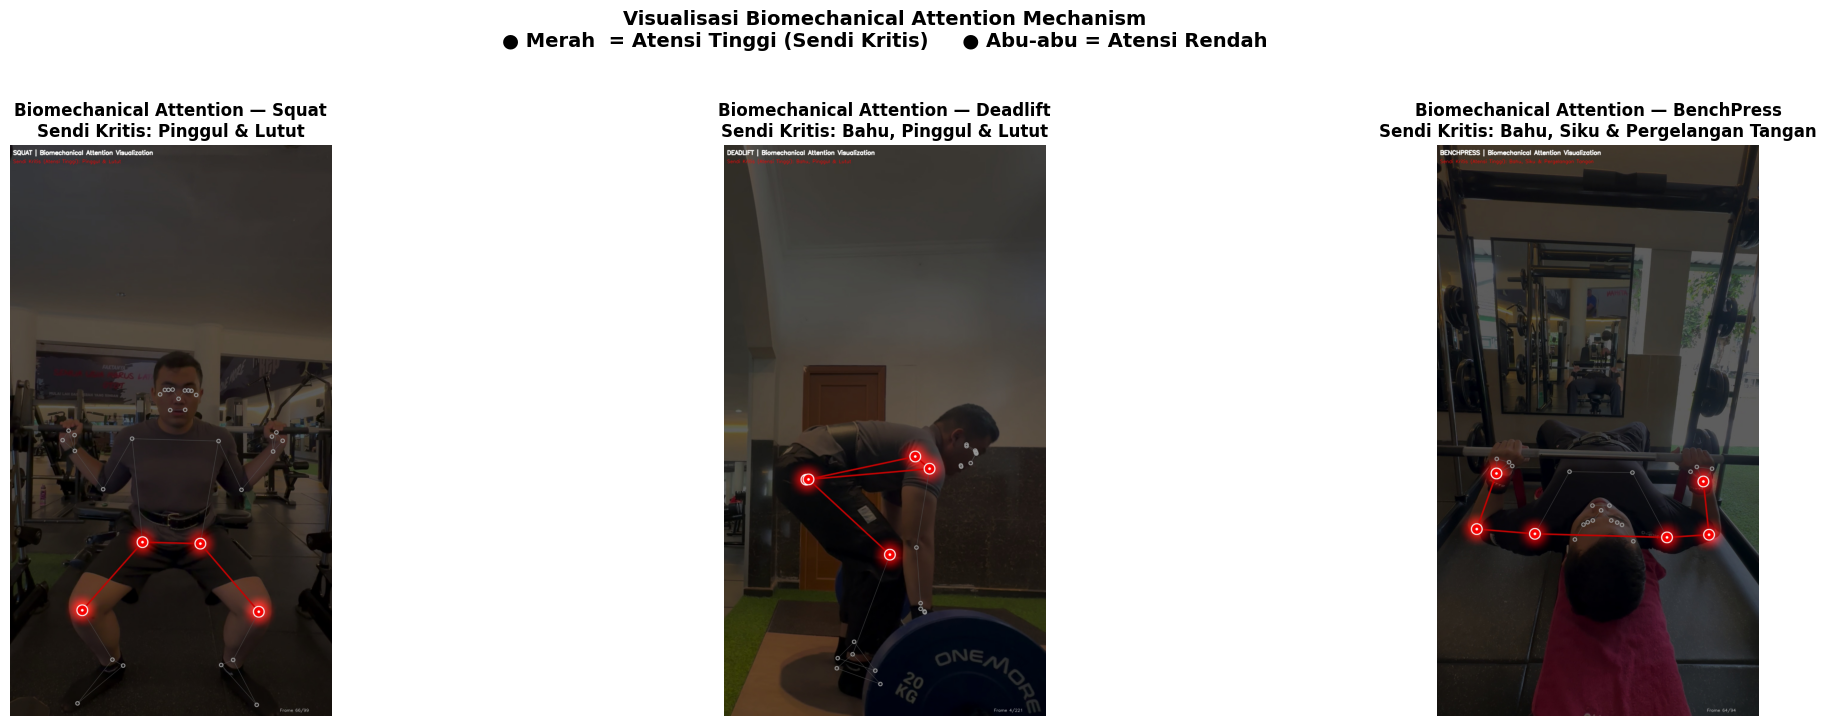


Semua file output tersimpan di: D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\processed
  attention_squat.mp4  &  attention_squat.jpg
  attention_deadlift.mp4  &  attention_deadlift.jpg
  attention_benchpress.mp4  &  attention_benchpress.jpg


In [5]:
# ============================================================
# Cari 1 file .mp4 dari setiap folder latihan secara otomatis
# ============================================================
RAW_ROOT = Path("../data/raw")

# Peta jenis latihan → path folder pencarian video
SAMPEL_LATIHAN = {
    "Squat"      : RAW_ROOT / "Squat",
    "Deadlift"   : RAW_ROOT / "Deadlift",
    "BenchPress" : RAW_ROOT / "BenchPress",
}

print("Mencari file video sampel...")
sampel_tugas: dict = {}  # { exercise_type: Path ke file video .mp4 }

for exercise_type, folder in SAMPEL_LATIHAN.items():
    if not folder.exists():
        print(f"  [SKIP] {exercise_type:12s}: Folder tidak ditemukan  → {folder}")
        continue

    video_files = sorted(folder.glob("*.mp4"))
    if video_files:
        sampel_tugas[exercise_type] = video_files[0]
        print(f"  [OK]   {exercise_type:12s}: {video_files[0].name}")
    else:
        print(f"  [SKIP] {exercise_type:12s}: Tidak ada .mp4 di {folder}")

if not sampel_tugas:
    print("\n[PERINGATAN] Tidak ada video sampel ditemukan!")
    print("Pastikan ada file .mp4 di salah satu folder berikut:")
    for ex_type, folder in SAMPEL_LATIHAN.items():
        print(f"  {folder}/")
else:
    print(f"\nTotal: {len(sampel_tugas)} jenis latihan akan divisualisasikan.\n")

    # ── Jalankan visualisasi untuk setiap sampel ──────────────────────────────
    image_results: dict = {}   # { exercise_type: path_file_jpg }

    for exercise_type, video_path in sampel_tugas.items():
        print(f"\n{'='*60}")
        print(f"Memproses: {exercise_type}  —  {video_path.name}")
        print("="*60)
        try:
            _, image_out = visualize_biomechanical_attention(
                video_path    = str(video_path),
                exercise_type = exercise_type,
                output_name   = exercise_type.lower(),   # "squat" / "deadlift" / "benchpress"
            )
            if image_out is not None:
                image_results[exercise_type] = image_out
        except Exception as err:
            print(f"  [ERROR] Gagal memproses {exercise_type}: {err}")

    # ── Tampilkan gambar hasil di dalam output Jupyter ────────────────────────
    if image_results:
        n_img = len(image_results)
        fig, axes = plt.subplots(1, n_img, figsize=(8 * n_img, 7))

        # Pastikan axes selalu berupa list (bukan single AxesSubplot) walau n_img=1
        if n_img == 1:
            axes = [axes]

        for ax, (exercise_type, image_path) in zip(axes, image_results.items()):
            # mpimg.imread membaca JPEG sebagai RGB
            # → warna ditampilkan dengan benar tanpa konversi tambahan
            img = mpimg.imread(image_path)
            ax.imshow(img)
            ax.set_title(
                f"Biomechanical Attention — {exercise_type}\n"
                f"Sendi Kritis: {ATTENTION_CONFIG[exercise_type]['label_kunci']}",
                fontsize=12,
                fontweight="bold",
            )
            ax.axis("off")  # Sembunyikan sumbu koordinat

        fig.suptitle(
            "Visualisasi Biomechanical Attention Mechanism\n"
            "● Merah  = Atensi Tinggi (Sendi Kritis)     "
            "● Abu-abu = Atensi Rendah",
            fontsize=14,
            fontweight="bold",
            y=1.03,
        )
        plt.tight_layout()
        plt.show()

        # Ringkasan file output yang tersimpan
        print(f"\nSemua file output tersimpan di: {Path('../data/processed').resolve()}")
        for ex_type in image_results:
            out_name = ex_type.lower()
            print(f"  attention_{out_name}.mp4  &  attention_{out_name}.jpg")
    else:
        print("[PERINGATAN] Tidak ada gambar yang berhasil dihasilkan.")
        print("Periksa apakah video .mp4 berisi pose yang dapat dideteksi MediaPipe.")